In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("cleaned_data.csv")

In [2]:
df.columns

Index(['Unnamed: 0', 'patient_id', 'age', 'gender', 'neighborhood',
       'scheduled_day', 'appointment_day', 'waiting_days', 'appointment_hour',
       'month', 'sms_received', 'reminder_calls', 'previous_appointments',
       'previous_no_shows', 'no_show_rate', 'distance_km',
       'transportation_type', 'has_chronic_disease', 'hypertension',
       'diabetes', 'alcoholism', 'disability', 'appointment_type',
       'doctor_specialty', 'clinic_type', 'weather_condition',
       'temperature_celsius', 'rainy_day', 'employment_status', 'income_level',
       'marital_status', 'children_count', 'patient_satisfaction_score',
       'no_show_probability', 'no_show'],
      dtype='object')

## In this part we believe that we will be able to analyze more than two variables and see there effect in the no_show rate.

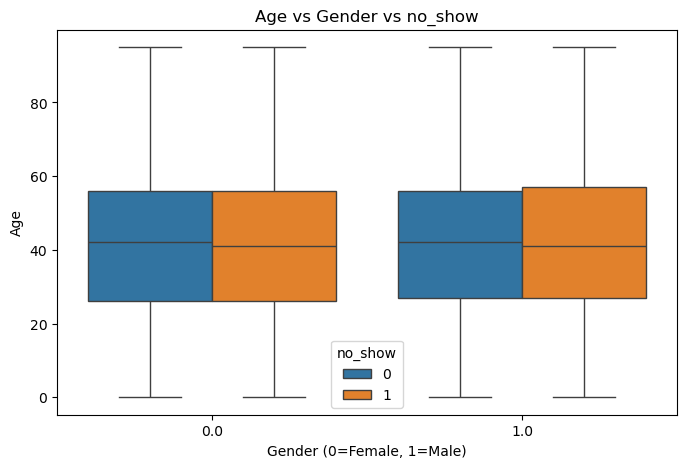

In [3]:
plt.figure(figsize=(8,5))
sns.boxplot(x='gender', y='age', hue='no_show', data=df)
plt.title('Age vs Gender vs no_show')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Age')
plt.legend(title='no_show')

Based on this visualization, Age and Gender do not appear to be strong standalone predictors for whether a patient will be a "no-show." The distributions between those who showed up and those who did not overlap almost completely. This suggests that the model will likely need to rely on other variables—or non-linear interactions between features—to find a meaningful predictive signal for appointment attendance.

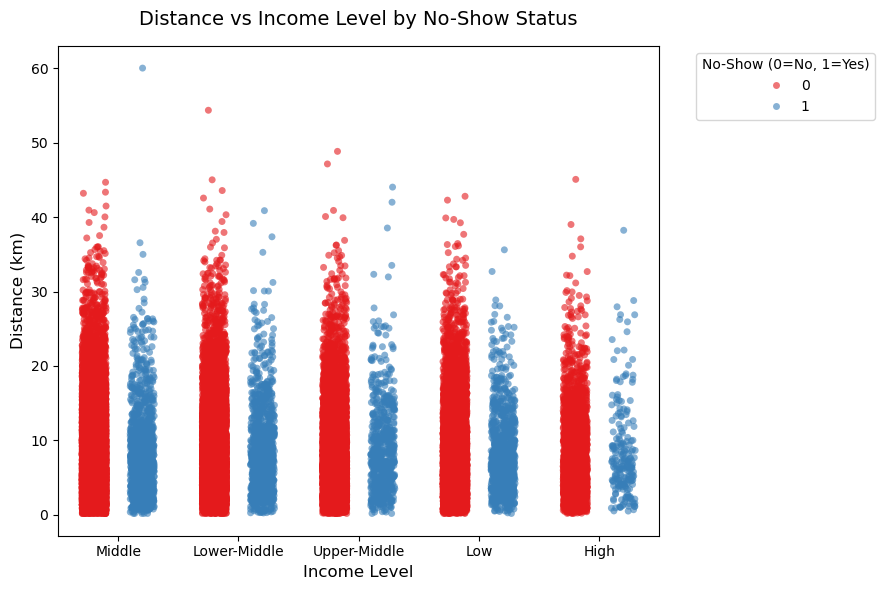

In [4]:
plt.figure(figsize=(9, 6))
sns.stripplot(
    x='income_level',
    y='distance_km',
    hue='no_show',
    data=df,
    dodge=True,      # BEST PARAMETER: Separates '0' and '1' side-by-side rather than overlapping them
    jitter=0.2,      # BEST PARAMETER: Adds horizontal scatter so points don't stack directly on top of each other
    alpha=0.6,       # Transparency to show density
    palette='Set1'   # High contrast colors for clarity
)
plt.title('Distance vs Income Level by No-Show Status', fontsize=14, pad=15)
plt.xlabel('Income Level', fontsize=12)
plt.ylabel('Distance (km)', fontsize=12)

plt.legend(title='No-Show (0=No, 1=Yes)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

This is evident from the plot that the highest number of patients reside on the low to middle class income. When looking at the no_show rate, "high" income people show the least no_show. However, the low to middle class people show higher no_show rates. Other than that, as the factors look pretty similar it is hard to find a proper trend.

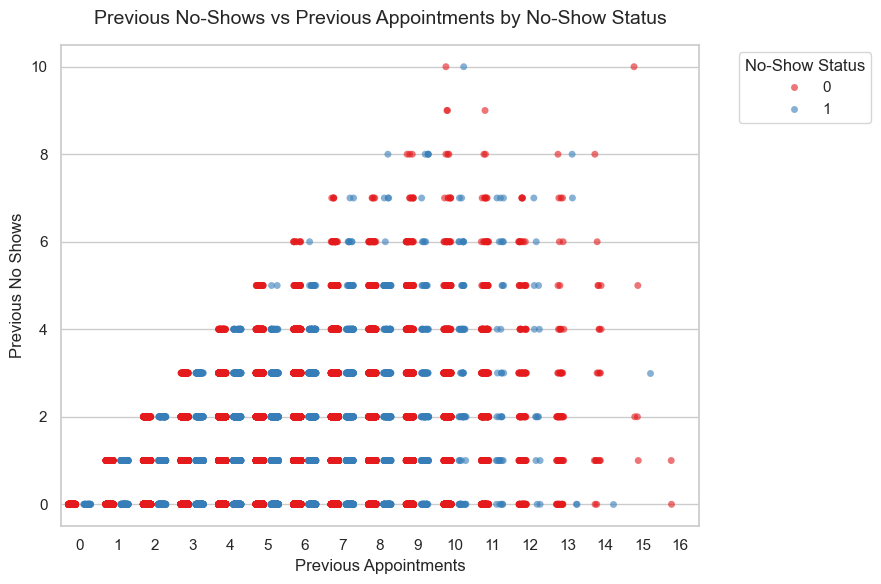

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 6))
sns.stripplot(
    x='previous_appointments',
    y='previous_no_shows',
    hue='no_show',
    data=df,
    dodge=True,      # BEST PARAMETER: Separates '0' and '1' side-by-side rather than overlapping
    jitter=0.2,      # BEST PARAMETER: Adds horizontal scatter so points don't stack directly
    alpha=0.6,       # Transparency to show density
    palette='Set1'   # High contrast colors for clarity
)

plt.title('Previous No-Shows vs Previous Appointments by No-Show Status', fontsize=14, pad=15)
plt.xlabel('Previous Appointments', fontsize=12)
plt.ylabel('Previous No Shows', fontsize=12)

plt.legend(title='No-Show Status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Observation: Historical Attendance vs. No-Show Status
Data Integrity Verified: The upper-left quadrant is entirely empty, which correctly reflects that a patient cannot have more "Previous No-Shows" than "Total Previous Appointments."

Population Skew: The highest density of points falls between 0 and 3 previous appointments, indicating that the vast majority of the dataset consists of new or infrequent patients.

The "Reliable" Cohort: There is a distinct cluster of patients in the bottom-right (e.g., 10+ previous appointments, 0 prior no-shows). These frequent patients are highly reliable and rarely miss current appointments.

Predictive Power: Within any specific vertical column (e.g., patients with exactly 6 previous appointments), as the number of past no-shows increases, the proportion of actual current no-shows (blue points) visibly rises. This visually confirms that a patient's historical no-show rate is a strong predictor of their future attendance.

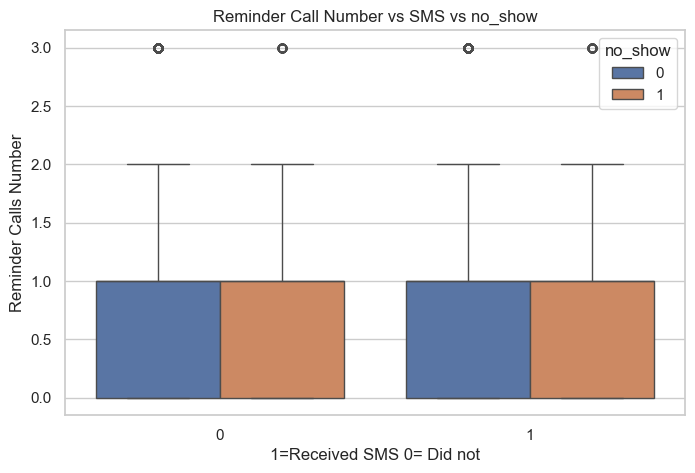

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sms_received', y='reminder_calls', hue='no_show', data=df)
plt.title('Reminder Call Number vs SMS vs no_show')
plt.xlabel('1=Received SMS 0= Did not')
plt.ylabel('Reminder Calls Number')
plt.legend(title='no_show')

Observation: Impact of Outreach Interventions (Calls & SMS)

The distributions for the number of reminder calls are completely identical regardless of whether a patient received an SMS or whether they ultimately showed up for their appointment.

This uniform distribution indicates that these specific intervention features (SMS and Call count) currently offer no statistical differentiation between "shows" and "no-shows".

<Figure size 1200x1200 with 0 Axes>

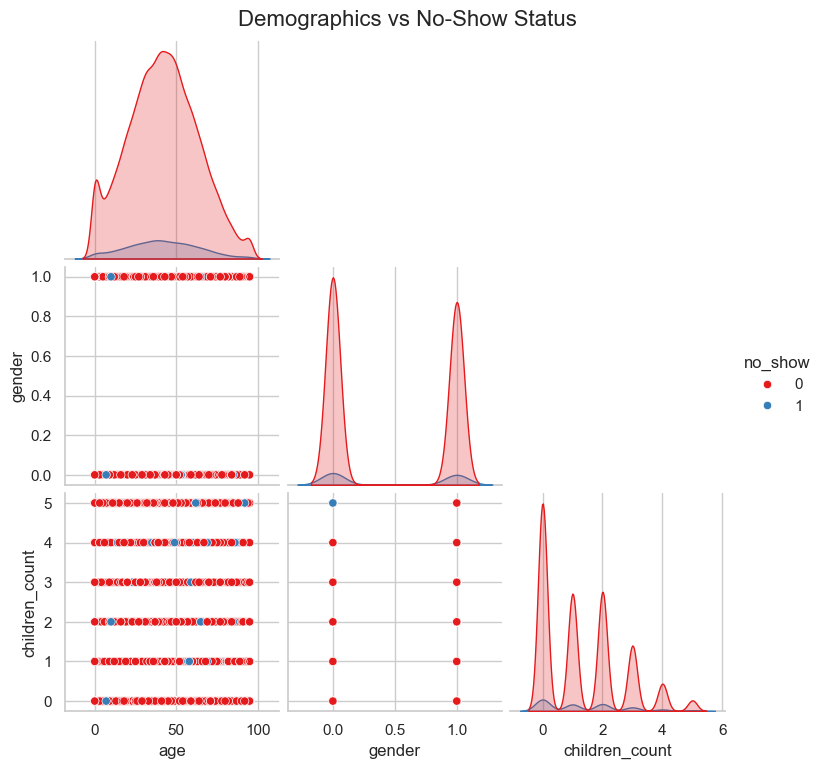

In [7]:
demo_cols = ['age', 'gender', 'employment_status', 'income_level', 'children_count', 'no_show']
df_demo = df[demo_cols]

plt.figure(figsize=(12, 12))
sns.pairplot(
    data=df_demo, 
    hue='no_show', 
    palette='Set1',
    corner=True,    
    diag_kind='kde' 
)
plt.suptitle('Demographics vs No-Show Status', y=1.02, fontsize=16)
plt.show()

Observation: Demographic Pairplot Analysis

Target Imbalance: The visual is heavily dominated by class 0 (patients who showed up), indicating our dataset has a low overall no-show rate.

Demographic Skew: The age distribution reveals a significant volume of infant patients (age 0). The children_count is heavily right-skewed, with the majority of the population reporting 0 children.

Visual Limitations of Discrete Data: Because features like gender and children_count are discrete/categorical, the standard scatter plots suffer from severe overplotting. We cannot accurately see the ratio of no-shows to regular shows in these dense clusters.

Takeaway for Modeling: To understand how demographics truly impact the no-show rate, we need to move away from raw counts/scatter plots and look at the proportional no-show rate (the mean) for each demographic group.

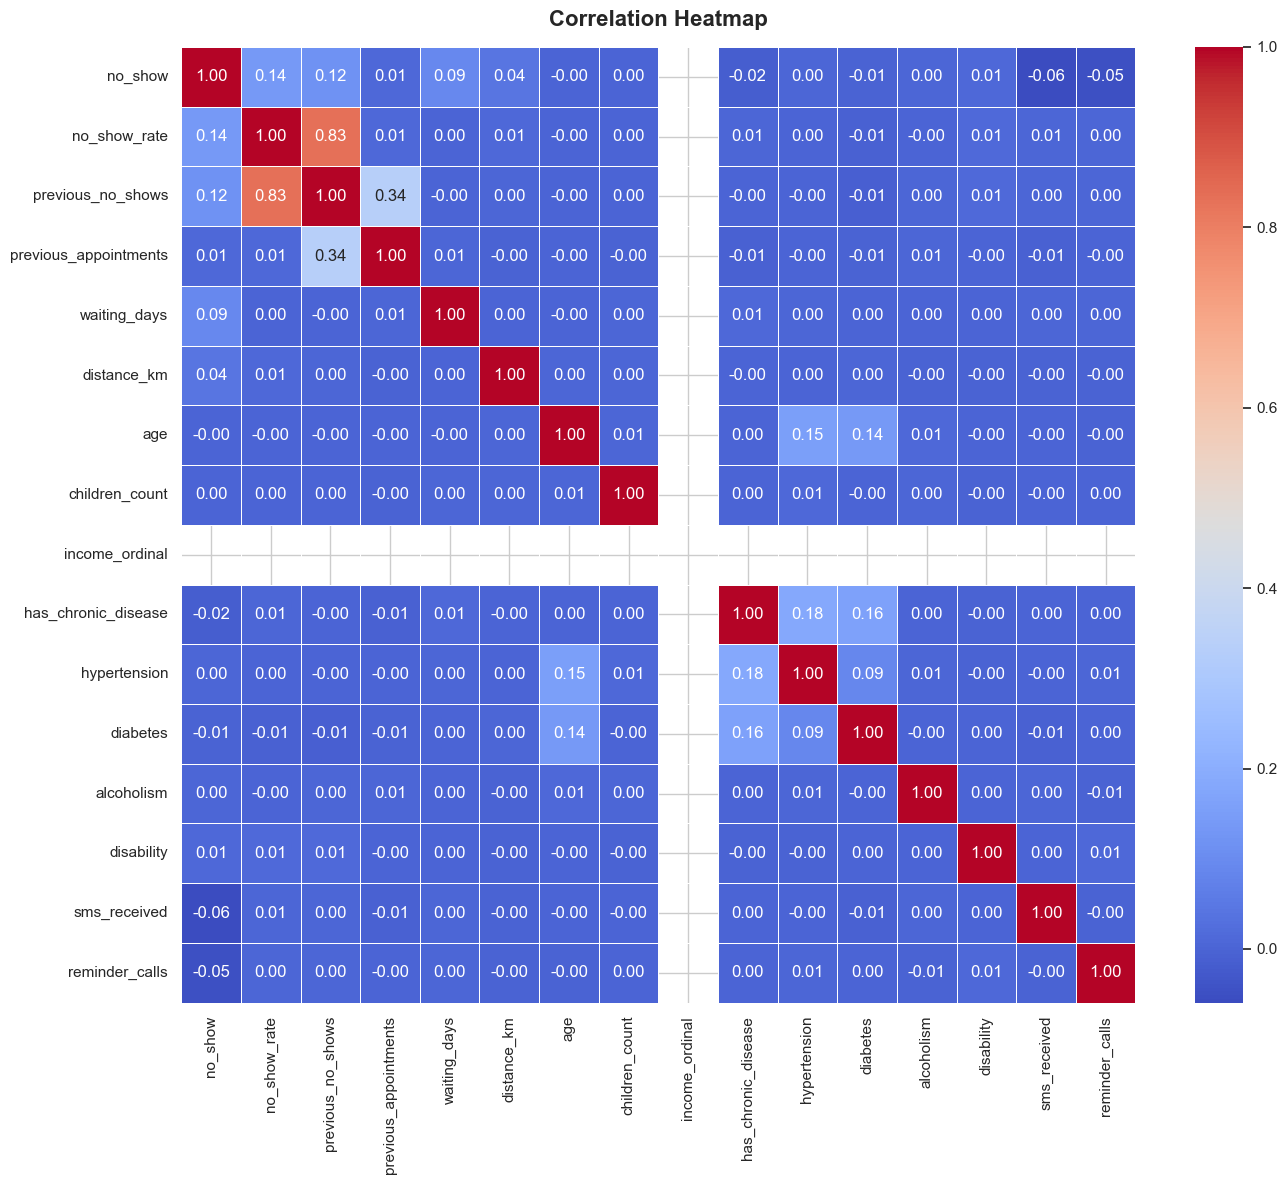

In [13]:
df['income_ordinal'] = df['income_level'].map({
    'Low': 1, 'Lower-Middle': 2, 'Middle': 3, 'Upper-Middle': 4, 'High': 5
})

heatmap_columns = [
    'no_show', 'no_show_rate', 'previous_no_shows', 'previous_appointments', 
    'waiting_days', 'distance_km', 'age', 'children_count', 'income_ordinal',
    'has_chronic_disease', 'hypertension', 'diabetes', 'alcoholism', 'disability',
    'sms_received', 'reminder_calls'
]

df_heatmap = df[heatmap_columns]

plt.figure(figsize=(14, 12))

sns.heatmap(
    df_heatmap.corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f",      
    linewidths=0.5  
)

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

It is visible from the correlation heatmap that maximum of the variables are quite independent as they do not depend much upon other variables. However, some small dependencies are notable:

1. Previous No show and No Show Rate has a positive 0.83 correlation which is very strong. This means that patients with more previous no shows are going to have a higher no show rate as expected.
2. No Show Rate and Previous No Show has a small correlation of 0.14 and 0.12 respectively. This means patients with higher previous no shows are more likely to miss a future appointment.
3. The more the previous appointments, the more the number of previous show increases as expected.
4. Hypertension and Diabetes has a correlation of 0.15 and 0.14 with age. This means elderly patients are more likely to have these diseases.

## Key Insights:

1. Age and Gender differences are not strong predictors for whether a patient would show up or not.
2. Low to Middle class income people are more likely to show higher no_show rates.
3. There are some patients who rarely misses an appointment. If the patient has a previous history of no_shows he/she is likely to miss more appointments.
4. According to this specific dataset, previous SMS and reminder calls are not strong predictors whether a patient will show up or not.